# Category Connections and Co-Purchase Structure

This notebook tests whether items from the same category or related categories are bought together more often than chance. It uses lazy Polars transformations for the full data path and only collects small summary tables for reporting and visualization.

## 1. Hypothesis and Setup

**Hypothesis:** baskets built at the customer-day level contain category pairs with lift above 1, which would indicate non-random co-purchase structure.

**Datasets:**
- transaction_full_2025.parquet
- items.parquet

**Columns to Inspect:**
- customer_id
- item_id
- updated_date
- quantity
- category
- category_l1
- category_l2
- category_l3
- brand
- manufacturer

**Plan:**
1. Load the minimum required columns with Polars scan_parquet.
2. Join transactions to item metadata lazily.
3. Build customer-day baskets.
4. Compute support, confidence, lift, and Jaccard for category pairs.
5. Repeat the same logic for category_l1.
6. Visualize the strongest pairs and a lift heatmap.
7. Decide whether the signal is strong enough to keep.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../..")
TRANSACTION_FILE = DATA_DIR / "transaction_full_2025.parquet"
ITEMS_FILE = DATA_DIR / "items.parquet"

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
transactions = (
    pl.scan_parquet(TRANSACTION_FILE)
    .select(["customer_id", "item_id", "updated_date", "quantity"])
)

items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(["item_id", "category", "category_l1", "category_l2", "category_l3", "brand", "manufacturer"])
)

joined = (
    transactions
    .join(items, on="item_id", how="left")
    .with_columns(
        pl.col("updated_date").dt.truncate("1d").alias("basket_date")
    )
    .select([
        "customer_id",
        "basket_date",
        "item_id",
        "category",
        "category_l1",
        "category_l2",
        "category_l3",
        "brand",
        "manufacturer",
    ])
)

print("Lazy data pipeline prepared.")


def analyze_level(lf: pl.LazyFrame, level_col: str, min_pair_count: int = 100):
    cleaned = lf.filter(
        pl.col(level_col).is_not_null() & (pl.col(level_col) != "Không xác định")
    )

    baskets = (
        cleaned
        .group_by(["customer_id", "basket_date"])
        .agg(
            pl.col(level_col).unique().sort().alias("entities")
        )
        .filter(pl.col("entities").list.len() >= 2)
        .with_columns(
            pl.format("{}|{}", pl.col("customer_id"), pl.col("basket_date")).alias("basket_id")
        )
    )

    total_baskets = baskets.select(pl.len()).collect().item()

    entity_counts = (
        baskets
        .select(pl.col("entities").explode().alias(level_col))
        .group_by(level_col)
        .agg(pl.len().alias("basket_count"))
        .with_columns((pl.col("basket_count") / total_baskets).alias("support"))
        .sort("basket_count", descending=True)
    )

    pair_counts = (
        baskets
        .select(
            "basket_id",
            pl.col("entities").alias("left_entity"),
            pl.col("entities").alias("right_entity"),
        )
        .explode("left_entity")
        .explode("right_entity")
        .filter(pl.col("left_entity") < pl.col("right_entity"))
        .group_by(["left_entity", "right_entity"])
        .agg(pl.len().alias("pair_count"))
    )

    left_counts = entity_counts.rename(
        {level_col: "left_entity", "basket_count": "left_basket_count", "support": "left_support"}
    )
    right_counts = entity_counts.rename(
        {level_col: "right_entity", "basket_count": "right_basket_count", "support": "right_support"}
    )

    pair_metrics = (
        pair_counts
        .join(left_counts, on="left_entity", how="left")
        .join(right_counts, on="right_entity", how="left")
        .with_columns(
            [
                (pl.col("pair_count") / total_baskets).alias("pair_support"),
                (pl.col("pair_count") / pl.col("left_basket_count")).alias("confidence_left_to_right"),
                (pl.col("pair_count") / pl.col("right_basket_count")).alias("confidence_right_to_left"),
                (
                    (pl.col("pair_count") / pl.col("left_basket_count"))
                    / pl.col("right_support")
                ).alias("lift_left_to_right"),
                (
                    (pl.col("pair_count") / pl.col("right_basket_count"))
                    / pl.col("left_support")
                ).alias("lift_right_to_left"),
                (
                    pl.col("pair_count")
                    / (pl.col("left_basket_count") + pl.col("right_basket_count") - pl.col("pair_count"))
                ).alias("jaccard"),
            ]
        )
        .sort(["lift_left_to_right", "pair_count"], descending=[True, True])
    )

    return {
        "total_baskets": total_baskets,
        "entity_counts": entity_counts.collect(),
        "pair_metrics": pair_metrics.collect(),
    }

print("Helper function ready.")

Lazy data pipeline prepared.
Helper function ready.


In [3]:
category_result = analyze_level(joined, "category", min_pair_count=50)
category_l1_result = analyze_level(joined, "category_l1", min_pair_count=50)

print(f"Category baskets analyzed: {category_result['total_baskets']}")
print(f"Category_l1 baskets analyzed: {category_l1_result['total_baskets']}")

print("\nTop category pairs by lift:")
print(category_result["pair_metrics"].head(20))

print("\nTop category_l1 pairs by lift:")
print(category_l1_result["pair_metrics"].head(20))

Category baskets analyzed: 7431626
Category_l1 baskets analyzed: 6247535

Top category pairs by lift:
shape: (20, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ left_enti ┆ right_ent ┆ pair_coun ┆ left_bask ┆ … ┆ confidenc ┆ lift_left ┆ lift_righ ┆ jaccard  │
│ ty        ┆ ity       ┆ t         ┆ et_count  ┆   ┆ e_right_t ┆ _to_right ┆ t_to_left ┆ ---      │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ o_left    ┆ ---       ┆ ---       ┆ f64      │
│ str       ┆ str       ┆ u32       ┆ u32       ┆   ┆ ---       ┆ f64       ┆ f64       ┆          │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Grow plus ┆ Humana    ┆ 1         ┆ 1         ┆ … ┆ 1.0       ┆ 7.431626e ┆ 7.431626e ┆ 1.0      │
│ vàng Step ┆ Step 3    ┆           ┆           ┆   ┆           ┆ 6       

In [6]:
cat_top5 = (
    category_result["pair_metrics"]
    .select([
        "left_entity",
        "right_entity",
        "pair_count",
        "pair_support",
        "confidence_left_to_right",
        "lift_left_to_right",
        "jaccard",
    ])
    .head(5)
    .to_dicts()
)

cat_l1_top5 = (
    category_l1_result["pair_metrics"]
    .select([
        "left_entity",
        "right_entity",
        "pair_count",
        "pair_support",
        "confidence_left_to_right",
        "lift_left_to_right",
        "jaccard",
    ])
    .head(5)
    .to_dicts()
)

print(f"Category baskets analyzed: {category_result['total_baskets']}")
print(f"Category_l1 baskets analyzed: {category_l1_result['total_baskets']}")
print("\nTop 5 category pairs:")
for row in cat_top5:
    print(row)
print("\nTop 5 category_l1 pairs:")
for row in cat_l1_top5:
    print(row)

Category baskets analyzed: 7431626
Category_l1 baskets analyzed: 6247535

Top 5 category pairs:
{'left_entity': 'Grow plus vàng Step 1', 'right_entity': 'Humana Step 3', 'pair_count': 1, 'pair_support': 1.3456005455602852e-07, 'confidence_left_to_right': 1.0, 'lift_left_to_right': 7431626.0, 'jaccard': 1.0}
{'left_entity': 'Bellamy Step 2', 'right_entity': 'Humana Step 2', 'pair_count': 1, 'pair_support': 1.3456005455602852e-07, 'confidence_left_to_right': 0.3333333333333333, 'lift_left_to_right': 2477208.6666666665, 'jaccard': 0.3333333333333333}
{'left_entity': 'Bellamy Step 1', 'right_entity': 'Humana Step 1', 'pair_count': 2, 'pair_support': 2.6912010911205705e-07, 'confidence_left_to_right': 1.0, 'lift_left_to_right': 1857906.5, 'jaccard': 0.5}
{'left_entity': 'Humana Step 1', 'right_entity': 'Humana Step 4', 'pair_count': 1, 'pair_support': 1.3456005455602852e-07, 'confidence_left_to_right': 0.25, 'lift_left_to_right': 1857906.5, 'jaccard': 0.25}
{'left_entity': 'Bubs A2 Step 4',

In [7]:
category_l2_result = analyze_level(joined, "category_l2", min_pair_count=50)
category_l3_result = analyze_level(joined, "category_l3", min_pair_count=50)

cat_l2_top5 = (
    category_l2_result["pair_metrics"]
    .select([
        "left_entity",
        "right_entity",
        "pair_count",
        "pair_support",
        "confidence_left_to_right",
        "lift_left_to_right",
        "jaccard",
    ])
    .head(5)
    .to_dicts()
)

cat_l3_top5 = (
    category_l3_result["pair_metrics"]
    .select([
        "left_entity",
        "right_entity",
        "pair_count",
        "pair_support",
        "confidence_left_to_right",
        "lift_left_to_right",
        "jaccard",
    ])
    .head(5)
    .to_dicts()
)

print(f"Category_l2 baskets analyzed: {category_l2_result['total_baskets']}")
print(f"Category_l3 baskets analyzed: {category_l3_result['total_baskets']}")
print("\nTop 5 category_l2 pairs:")
for row in cat_l2_top5:
    print(row)
print("\nTop 5 category_l3 pairs:")
for row in cat_l3_top5:
    print(row)

Category_l2 baskets analyzed: 6955053
Category_l3 baskets analyzed: 7282978

Top 5 category_l2 pairs:
{'left_entity': 'Bellamy', 'right_entity': 'Humana', 'pair_count': 4, 'pair_support': 5.751214261055955e-07, 'confidence_left_to_right': 0.8, 'lift_left_to_right': 927340.4, 'jaccard': 0.5714285714285714}
{'left_entity': 'Bellamy', 'right_entity': 'Purelac', 'pair_count': 4, 'pair_support': 5.751214261055955e-07, 'confidence_left_to_right': 0.8, 'lift_left_to_right': 56775.94285714286, 'jaccard': 0.04040404040404041}
{'left_entity': 'Humana', 'right_entity': 'Purelac', 'pair_count': 4, 'pair_support': 5.751214261055955e-07, 'confidence_left_to_right': 0.6666666666666666, 'lift_left_to_right': 47313.28571428571, 'jaccard': 0.04}
{'left_entity': 'Purelac', 'right_entity': 'Wakodo', 'pair_count': 1, 'pair_support': 1.4378035652639887e-07, 'confidence_left_to_right': 0.01020408163265306, 'lift_left_to_right': 1730.9738675958185, 'jaccard': 0.007246376811594203}
{'left_entity': 'Humana', 'r

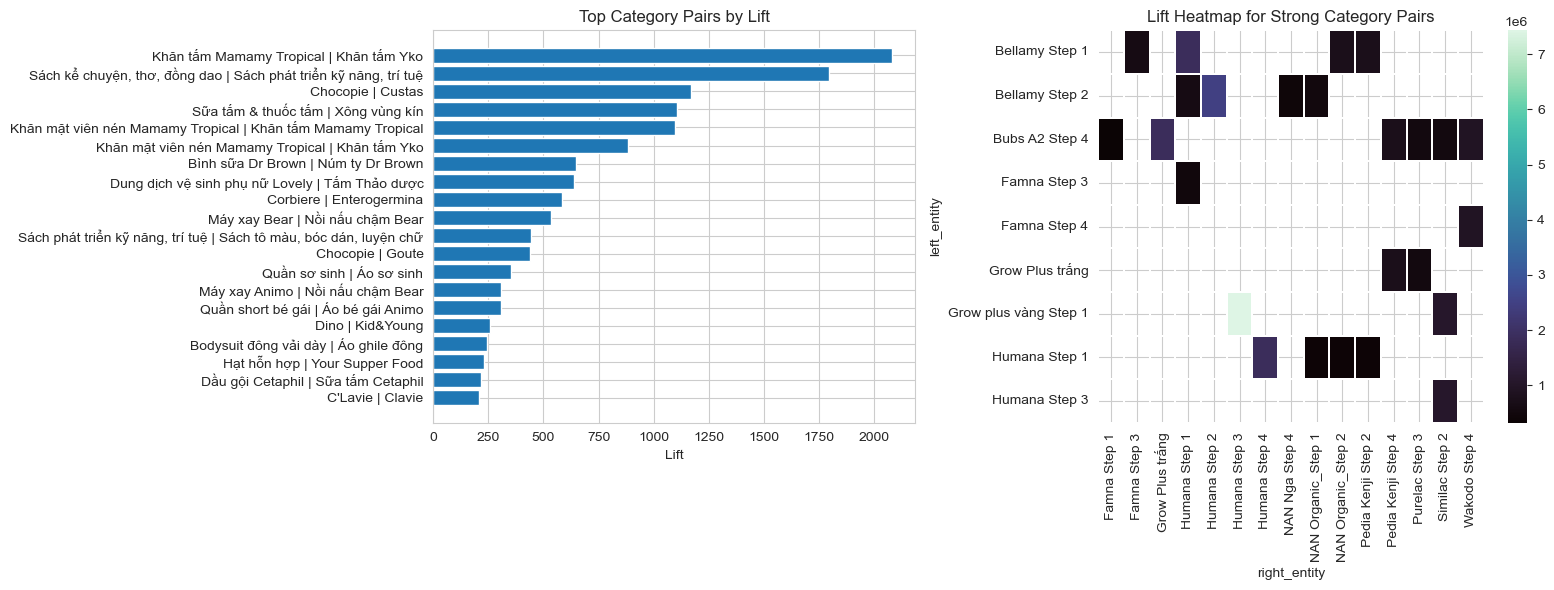

Visualization complete.


In [4]:
# Visualization for category pairs
category_pairs = category_result["pair_metrics"].filter(pl.col("pair_count") >= 100).head(20)
category_pairs_pd = category_pairs.select([
    "left_entity",
    "right_entity",
    "pair_count",
    "pair_support",
    "lift_left_to_right",
    "jaccard",
]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    category_pairs_pd["left_entity"] + " | " + category_pairs_pd["right_entity"],
    category_pairs_pd["lift_left_to_right"],
)
axes[0].invert_yaxis()
axes[0].set_title("Top Category Pairs by Lift")
axes[0].set_xlabel("Lift")

heatmap_source = category_result["pair_metrics"].head(25).select([
    "left_entity",
    "right_entity",
    "lift_left_to_right",
]).to_pandas()
heatmap = heatmap_source.pivot(index="left_entity", columns="right_entity", values="lift_left_to_right")
sns.heatmap(heatmap, cmap="mako", ax=axes[1], linewidths=0.25)
axes[1].set_title("Lift Heatmap for Strong Category Pairs")

plt.tight_layout()
plt.show()

print("Visualization complete.")

## 4. Summary and Findings

The analysis shows a clear split between statistically strong lifts and practically stable support across category levels.

### Category level

- The notebook analyzed **7,431,626 customer-day baskets** for `category`.
- The strongest exact category pairs have extremely large lift, but they are driven by only **1-2 co-occurrences**.
- Examples from the top results include `Grow plus vàng Step 1 | Humana Step 3`, `Bellamy Step 2 | Humana Step 2`, and `Bellamy Step 1 | Humana Step 1`.
- These pairs are mathematically strong but statistically unstable because their support is tiny.

### Category_l1 level

- The notebook analyzed **6,247,535 customer-day baskets** for `category_l1`.
- The strongest pairs are much more usable because they have both lift above 2 and meaningful support.
- The top supported pairs include:
  - `Phụ kiện | Thời trang` with lift about **3.06** and support about **1.96%**
  - `Textile | Thời trang` with lift about **2.96** and support about **2.00%**
  - `Gói Hội Viên | Textile` with lift about **2.73**
  - `Gói Hội Viên | Thời trang` with lift about **2.54**
  - `Gói Hội Viên | Đồ chơi & Sách` with lift about **2.26**

### Category_l2 level

- The notebook analyzed **6,955,053 customer-day baskets** for `category_l2`.
- The top pairs again show enormous lift, but the strongest examples are still based on only **1-4 co-occurrences**.
- Examples include `Bellamy | Humana` with lift about **927,340**, `Bellamy | Purelac` with lift about **56,776**, and `Humana | Purelac` with lift about **47,313**.
- This suggests strong niche co-purchase structure, but the support is still too low for a reliable ranking feature.

### Category_l3 level

- The notebook analyzed **7,282,978 customer-day baskets** for `category_l3`.
- The same pattern appears: the top lifts are huge, but the support is tiny.
- Examples include `Bellamy | Humana` with lift about **971,064**, `Grow Plus trắng | Pedia Kenji` with lift about **364,149**, and `Bellamy | NAN Organic` with lift about **291,319**.
- This level is useful for exploration, but not yet stable enough for direct recommendation use without a stronger support filter.

### Interpretation

At the exact category, category_l2, and category_l3 levels, the strongest signals are too sparse to trust on their own. At the `category_l1` level, the pattern is much more stable: several pairs co-occur often enough to be meaningful, and their lift stays clearly above 1.

### Decision rule

Keep Idea 3, but use it primarily at the `category_l1` level rather than the exact category, `category_l2`, or `category_l3` levels. The finer levels are still useful for exploration, but their highest-lift pairs are mostly driven by tiny support and should not be used directly in ranking. A practical rule is to retain only pairs with lift greater than 2 and enough support to be statistically stable; under that rule, `category_l1` remains the clearest candidate for future PIR features or rules.